In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load data
df = pd.read_csv('medical_examination.csv')

# Add 'overweight' column
df['overweight'] = (df['weight'] / ((df['height'] / 100) ** 2)).apply(lambda x: 1 if x > 25 else 0)

# Normalize cholesterol and gluc
df['cholesterol'] = df['cholesterol'].apply(lambda x: 0 if x == 1 else 1)
df['gluc'] = df['gluc'].apply(lambda x: 0 if x == 1 else 1)


In [5]:
def draw_cat_plot():
    df_cat = pd.melt(df,
                     id_vars='cardio',
                     value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'])

    df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')

    plot = sns.catplot(
        x='variable', y='total', hue='value', col='cardio',
        data=df_cat, kind='bar', height=5, aspect=1
    )

    fig = plot.fig
    return fig


In [6]:
def draw_heat_map():
    df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) &
        (df['height'] >= df['height'].quantile(0.025)) &
        (df['height'] <= df['height'].quantile(0.975)) &
        (df['weight'] >= df['weight'].quantile(0.025)) &
        (df['weight'] <= df['weight'].quantile(0.975))
    ]

    corr = df_heat.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr,
                mask=mask,
                annot=True,
                fmt=".1f",
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.5})
    return fig


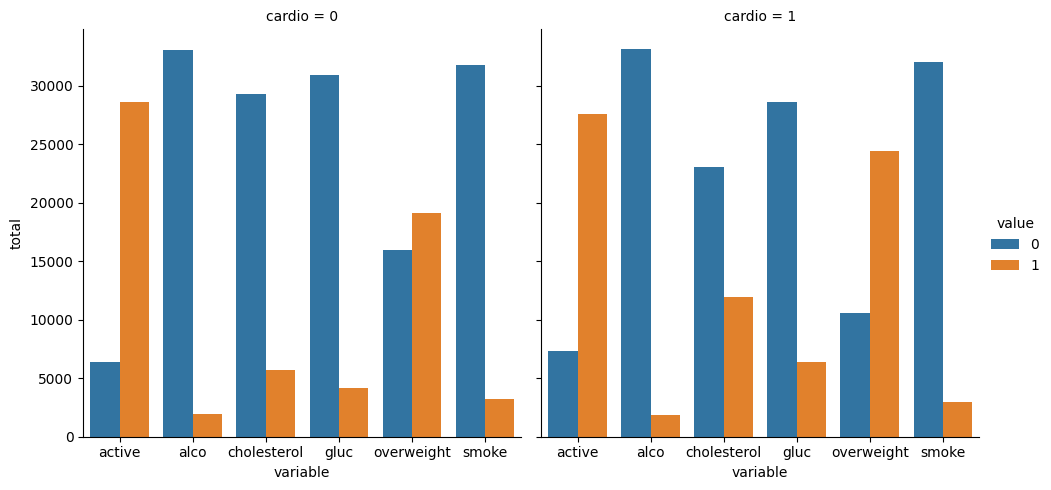

In [7]:
fig1 = draw_cat_plot()
fig1.savefig('catplot.png')  # Save if needed
plt.show()


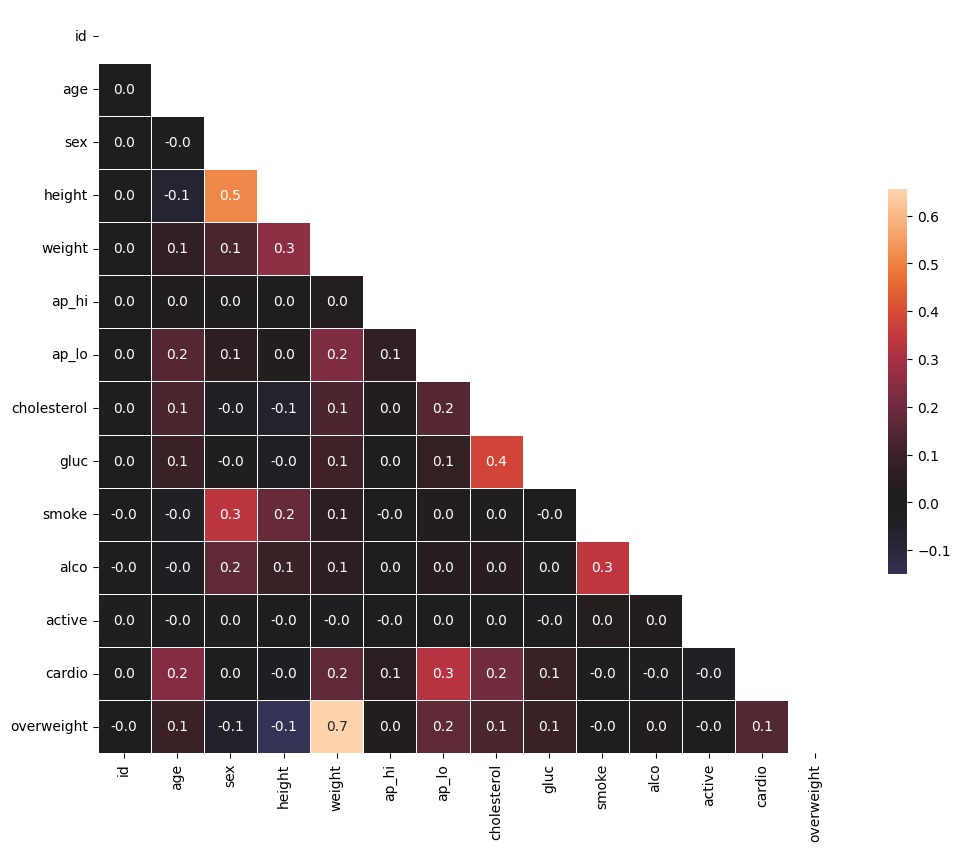

In [8]:
fig2 = draw_heat_map()
fig2.savefig('heatmap.png')  # Save if needed
plt.show()
